# ASTR 457: Foundations of Data Science in Astronomy

**Fall 2026, University of Illinois Urbana-Champaign**

Prof. Gautham Narayan | TA: Abha Vishwakarma

Tue Sep 8, 2026 - Day 5: two warnings, then estimators (on Zoom)

<img src="images/uiuc_logo.png" alt="University of Illinois Urbana-Champaign wordmark" width="220" style="display:block;margin:0 auto;">

## Today's plan

* **Quiz 1** first, about 15 minutes, proctored in the room: probability and robust statistics, nothing past Thursday.
* One more published failure that we did not reach on Thursday: BICEP2, the twin of CEERS-93316.
* Then, is there even a thick disk? Same stars, reweighted.
* Then new material: estimators (what makes one good, and how good can one be).

Remote again this week. I'd rather take a wrong turn out loud than lose half the room to silence: chat, or unmute.

In [18]:
# Presenter setup (a RISE "skip" cell: it runs, but is not a slide).
# Imports, and Thursday's SDSS SEGUE sample of Milky Way stars from astroML.
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.optimize import minimize
from astroML.datasets import fetch_sdss_sspp

data = fetch_sdss_sspp()
# the same quality cuts as Thursday
good = (data['FeHErr'] < 0.3) & (data['alphFeErr'] < 0.3) & (data['SNR'] > 20)
d = data[good]
alpha_poor = d[d['alphFe'] < 0.1]     # thin-disk-like stars
alpha_rich = d[d['alphFe'] > 0.3]     # thick-disk-like stars
feh = np.asarray(alpha_poor['FeH'])   # the [Fe/H] values we resample from today
print(f"{len(d)} stars; alpha-poor {len(alpha_poor)}, alpha-rich {len(alpha_rich)}")


252871 stars; alpha-poor 28148, alpha-rich 104427


## Recap

* Two [Fe/H] samples, a KS test: $D = 0.61$, $p$ underflowed to zero
    * $p \approx 0$ says almost nothing at $N = 130{,}000$ - any difference at all is "significant" with that many stars
    * $D = 0.61$ is the informative number: the two cumulative distributions are 61% apart at their widest, i.e. a big effect
* $p < 0.05$ is the conventional line for "significant": you accept being wrong 1 time in 20 when the null is true
* Three traps:
    * too little data: 8 stars miss a 0.75 dex gap more than half the time
    * too much data: 130,000 stars make any cut "significant"
    * too many tests: 20 tests give you one hit from nothing
* CEERS-93316: a narrow posterior at $z \approx 16$, spectroscopically $z = 4.91$

<div style="font-size:1.35em; line-height:1.45; margin:0.6em 0;">

**A tight error bar is a statement about the model. It does not tell you the model is right.**

</div>

Two loose ends from Thursday, then new material.

## Background: the polarised microwave sky

<img src="images/planck_cmb_polarisation.jpg" alt="Planck all-sky map of the cosmic microwave background in Mollweide projection, colour showing temperature and a fine streaked texture showing the direction of polarisation" width="820" style="display:block;margin:0 auto;">

<div style="font-size:0.8em; text-align:center; color:#666;">ESA and the Planck Collaboration, 2015. Colour: temperature; texture: polarisation direction, smoothed to 5 degrees.</div>

The cosmic microwave background is light released when the universe was about 380,000 years old, redshifted today into microwaves. It is faintly polarised, and a polarisation pattern on the sky splits into two kinds: a curl-free **E-mode** and a curl-like **B-mode**.

Inflation, the proposed burst of exponential expansion in the first fraction of a second, predicts primordial gravitational waves, and those are the dominant *primordial* source of B-modes. Their amplitude, relative to the ordinary density ripples, is the tensor-to-scalar ratio $r$. Measure $r > 0$ and you have the strongest available evidence for inflation.


## Three ways to make a B-mode

* inflation: primordial gravitational waves, amplitude $r$ (the signal everyone was after)
* lensing: everything between us and the CMB bends the light and turns some E-mode into B-mode (the "lensed $\Lambda$CDM" curve - $\Lambda$CDM is the standard cosmological model, so this is what you expect at $r = 0$)
* dust: polarised emission from grains in our own Galaxy, a foreground on top of everything

BICEP2 observed at one frequency, 150 GHz, where the CMB is bright. At one frequency you cannot tell dust from CMB. Planck mapped the whole sky in nine bands; its 353 GHz channel is dust-dominated (effectively a dust map).

<table style="border:none; margin:0 auto;"><tr style="border:none;"><td style="border:none; padding:4px; vertical-align:top;"><img src="images/bicep2_south_pole.jpg" alt="The Dark Sector Laboratory at the South Pole with the South Pole Telescope on the left and the BICEP2 telescope inside its ground shield on the right" width="470" style="display:block;margin:0 auto;"></td><td style="border:none; padding:4px; vertical-align:top;"><img src="images/planck_353ghz_dust.jpg" alt="Planck all-sky map of polarised dust emission at 353 GHz, darker where the polarised emission is stronger, with striations tracing the plane-of-sky magnetic field" width="560" style="display:block;margin:0 auto;"></td></tr></table>

<div style="font-size:0.8em; text-align:center; color:#666;">Left: Dark Sector Lab, South Pole; BICEP2 is the instrument in the ground shield at right (Ketiltrout, Wikimedia Commons, CC BY-SA 3.0). Right: Planck polarised dust at 353 GHz, 2014 (ESA and the Planck Collaboration).</div>

## BICEP2 and the dust

March 2014: BICEP2 announces primordial gravitational waves, $r \approx 0.2$, front-page news. 

<img src="images/bicep2_planck_dust.png" alt="B-mode power spectrum with black points from BICEP2 and Keck sitting above the lensed lambda-CDM curve, and blue points after subtracting the dust contribution measured against Planck falling onto that curve, with the likelihood for r below peaking near zero" width="480" style="display:block;margin:0 auto;">

<div style="font-size:0.8em; text-align:center; color:#666;">BICEP2/Keck and Planck Collaborations, PRL 114, 101301 (2015), Fig. 12. The subtraction uses the Planck 353 GHz dust map from the previous slide.</div>

* black points: BICEP2's raw B-mode signal, well above the lensing curve
* blue points: the same data after subtracting the dust measured against Planck 353 GHz - they sit on the lensing curve
* joint analysis, 2015: only an upper limit, $r < 0.12$ - the signal was Galactic dust
* a detail from the preprint: BICEP2 estimated the dust partly from a Planck map *digitised off a conference slide* (a talk at ESLAB 2013). Flauger, Hill & Spergel (2014) showed how far that could be off; the published paper dropped the model as having "unquantifiable uncertainty"

Same as CEERS-93316: the error bar on $r$ was tight because the model had no dust term, and more 150 GHz data would never have shown that. It took a second frequency, Planck at 353 GHz.

## "What if I'm tricked?"

<div style="font-size:1.35em; line-height:1.45; margin:0.6em 0;">

**"Let's just hope that this is not a trick. I always live with this feeling: what if I'm tricked? What if I believe in this just because it is beautiful?"**

</div>

<video controls width="560" src="media/linde_bicep2_2014.mp4" style="display:block;margin:0 auto;"></video>

<div style="font-size:0.8em; text-align:center; color:#666;">Andrei Linde at his front door, March 2014, on being told BICEP2 had found $r = 0.2$. Stanford University video, 3 min; the quote is at 1:56-2:05. The clip is not included in the repository (it plays from a local file in class) - watch it here: https://www.youtube.com/watch?v=ZlfIVEy_YOA</div>

* he had just been handed the confirmation of thirty years of his own work, and his first sentence after the champagne was about being fooled
* a year later it was dust. He was right to ask
* that question is what this course is for: not "is the result significant" but "what would it take for me to be wrong, and have I checked?"


## Back to the Milky Way

<img src="images/mw_thin_thick_disk_diagram.png" alt="Schematic edge-on Milky Way with the thin disk, the thicker and older thick disk, the bulge and the halo labelled" width="760" style="display:block;margin:0 auto;">

<div style="font-size:0.8em; text-align:center; color:#666;">Thin and thick disk, schematic NatashaFromEndor, CC BY-SA 4.0, via Wikimedia Commons.</div>

BICEP2 was somebody else's data, but the same problem sits underneath Thursday's demo - a conclusion driven by something that wasn't modelled (dust there, the selection function here). We split the SEGUE stars into two populations and they differ. But is there *really* a second disk?

* the thick disk began as a *geometric* claim (Gilmore & Reid 1983): star counts against height above the mid-plane need a second, thicker exponential - the **scale height** is that exponential's e-folding thickness
* a **mono-abundance population** is every star in one small box of the [Fe/H]-[alpha/Fe] plane
* if there are two disks, sort the boxes by scale height and you should get two clumps, thin and thick

## One disk, continuously thicker

Bovy, Rix & Hogg (2012, *ApJ*, 751, 131; arXiv:1111.6585) make two arguments against a distinct thick disk. The geometric one first: they ran mono-abundance sub-populations from this same SEGUE survey through a spatial-structure analysis and found "no hint of a thin-thick disk bi-modality": disk thickness runs continuously from 200 to 1100 pc.

<img src="images/bovy2012_scaleheight_continuum.png" alt="Surface mass density against vertical scale height for mono-abundance populations, coloured by alpha to iron ratio, with points filling 200 to 1100 parsecs smoothly and no gap or second clump" width="760" style="display:block;margin:0 auto;">

<div style="font-size:0.8em; text-align:center; color:#666;">Bovy, Rix &amp; Hogg 2012, ApJ 751, 131, Fig. 2. If there were a distinct thick disk, there would be a gap here.</div>


## Counts vs. mass

The second argument is the weighting. Our very first plot on Thursday was a *number count*: one dot per star that made it into the catalogue. Bovy, Rix & Hogg reweight each star by the stellar mass it stands for, divided by the probability that a star like it survived SEGUE's selection cuts (the **selection function**) - and the second clump goes away.

<table style="border:none; margin:0 auto;"><tr style="border:none;">
<td style="border:none; padding:4px;"><img src="images/bovy2012_raw_counts.png" alt="Alpha to iron versus iron abundance for the raw SEGUE sample counts, whose marginal alpha histogram shows a peak near 0.1 and a second bump near 0.4" width="430" style="display:block;margin:0 auto;"></td>
<td style="border:none; padding:4px;"><img src="images/bovy2012_mass_weighted.png" alt="The same plane weighted by stellar mass, whose marginal alpha histogram is a single peak near 0.1 falling away monotonically" width="430" style="display:block;margin:0 auto;"></td>
</tr></table>

<div style="font-size:0.8em; text-align:center; color:#666;">Bovy, Rix &amp; Hogg 2012, ApJ 751, 131, Fig. 1. Watch the right-hand marginal histogram in each panel.</div>

* I can't redo that on our sample in class: it needs SEGUE's selection function and a mass weight per star, which the astroML table doesn't include - the first of four open problems in this dataset, in the **EXTRA** cell that follows in the notebook (not presented today)
* I've been calling this thin disk vs. thick disk all class, which is simpler than the actual state of the field: same data, a different weighting, and the case for two populations is a lot weaker

## EXTRA: open problems in this dataset

*Not presented in class - four projects this dataset supports, for anyone who wants one.*

You have the pieces these need: the selection caveats, the KS test, and the QQ-plot.

* **Correct the selection function.** Forward-model the catalogue's ten selection cuts through a Milky Way stellar-population model. How does the [Fe/H]-[alpha/Fe] distribution you infer change once selection is accounted for?
* **Cross-check against modern astrometry.** This is SEGUE data from SDSS DR9 (2012). Gaia (ESA's astrometry satellite, launched 2013) now gives parallaxes and proper motions for 1.8 billion stars, these included. **Do the thin and thick disk populations hold up once you add real distances and orbits to the chemistry?**
* **Chemistry against kinematics.** This catalogue has radial velocities and proper motions in it, unused in our demo. **Do chemically-defined and kinematically-defined populations agree about which stars belong to which disk?** They don't always.
* **Age-abundance relations.** No ages here, but cross-match against surveys that have them - asteroseismology (ages from a star's surface oscillation frequencies, from Kepler and TESS light curves) or isochrone fitting (placing a star on model tracks of luminosity and temperature against age). **Does alpha-rich always mean old?**


## KS test: things to remember

* The two [Fe/H] distributions do differ: $D = 0.61$, $p$ underflowed - and at 130,000 stars it is $D$ that says the difference is *big*
* It is a weaker claim than "there are two disk populations": a KS test compares two *samples*; bimodality of the parent population is a separate claim, the one Bovy, Rix & Hogg dispute
* Report the effect size, and how many tests you ran, alongside $p$ (neither of which an AI assistant will add for you)

Two of Thursday's failures were a number with an error bar, and the error bar was wrong: CEERS's narrow posterior and BICEP2's $r = 0.2$. The third, the two-disk split, was a conclusion that a reweighting dissolves - no error bar would have warned you. Today we go back to where a number and its error bar come from, and what the error bar actually promises - and we'll check that promise by running the repeat experiments Thursday's examples never got.


## Estimators

Thursday was about deciding; today is about measuring: you have data, you want a number, and you want to know how good the number is.

* an estimator is a function of the data that returns a number (and it is a random variable)
* the properties we want from an estimator: bias, variance, consistency, efficiency
* the likelihood, its connection to $\chi^2$, and why the width of its peak is your error bar
* the Cramér-Rao bound, the best any unbiased estimator can do
* what a 68% error bar means

Let's start with one measurement, the one Gaia makes 1.8 billion times - a parallax.

## Gaia parallaxes

<img src="images/gaia_spacecraft.jpg" alt="Artist impression of the Gaia spacecraft, sunshield and payload module, in front of the Gaia all-sky image of the Milky Way" width="700" style="display:block;margin:0 auto;">

<div style="font-size:0.8em; text-align:center; color:#666;">Spacecraft: ESA/ATG medialab; Milky Way: ESA/Gaia/DPAC; acknowledgement A. Moitinho. CC BY-SA 3.0 IGO</div>

* Gaia watches a star's position shift as the Earth goes round the Sun; half the angular size of that wobble is the **parallax**
* notation: astronomers write parallax as $\varpi$ (a variant of $\pi$, pronounced "pi" or "varpi"); $\varpi$ is the true value, $\hat\varpi$ the measured one (the hat means "estimate" all day today)
* geometry: $d = 1/\varpi$, i.e. one arcsecond is one parsec, one milliarcsecond (mas) is one kiloparsec
* Gaia never measures a parallax directly: it fits five numbers (2 for position, 1 parallax, 2 for proper motion, the drift across the sky) to hundreds of positions along its scans, and the parallax is one coefficient of that fit. Noise can push a coefficient below zero; nothing in the fit forbids it, and throwing the negative ones away would bias the catalogue
* the catalogue gives you $\hat\varpi$ and an error bar $\sigma_\varpi$, and you want a distance. So just divide...

## How well Gaia measures it

<img src="images/gaia_dr3_parallax_error_vs_g.png" alt="Density plot of Gaia EDR3 parallax uncertainty against G magnitude, a floor near 0.02 milliarcseconds for bright stars rising to about one milliarcsecond at the faint limit" width="900" style="display:block;margin:0 auto;">

<div style="font-size:0.8em; text-align:center; color:#666;">Lindegren et al. 2021, A&amp;A 649, A2, Fig. 7. ESA/Gaia/DPAC.</div>

* $x$-axis: $G$ magnitude (Gaia's own broad optical band; brighter to the left); $y$-axis: parallax uncertainty $\sigma_\varpi$ in mas, log scale (curves: 10th, 50th and 90th percentiles)
* left: stars with the standard 5-parameter astrometric solution (position, parallax, proper motion); right: the 6-parameter solution for stars whose colour was too poorly known, (adds a colour term, a little worse)
* 0.02-0.03 mas for bright stars ($G < 15$), 0.5 mas at $G = 20$: a star at 1 kpc (a 1 mas parallax) is a 2% measurement if bright and a 50% one if faint (and the faint ones are most of the 1.8 billion)

## A star in the catalogue

<div style="font-size:1.15em; line-height:1.4; margin:0.6em 0; padding:0.5em 0.8em; border-left:4px solid #444; background:#f2f2f2;">

🎤 Gaia reports $\hat\varpi = -0.3 \pm 0.5$ mas for a star. What is its distance?

</div>


## Estimators as random variables

Let's say we have one star at 1 kpc, so $\varpi = 1$ mas, and Gaia measures it once with Gaussian noise. That single number is $\hat\varpi$, and $1/\hat\varpi$ is our estimate of the distance.

Now imagine the mission flown again, and again - ten thousand hypothetical Gaias, each returning a slightly different $\hat\varpi$. Each estimate is one draw from a distribution, so the estimator has a mean, a width and a shape of its own - it's reasonable to ask how good it is.

(note: these are imaginary repeated experiments - this is the frequentist view, where a probability is a long-run frequency over repeats; the Bayesian view is next week)

<div style="font-size:1.35em; line-height:1.45; margin:0.6em 0;">

**Estimators are themselves random variables: they are determined by the data, and the data are random.**

</div>

In [19]:
# Ten thousand hypothetical Gaia missions, each measuring the same star once.
# The true parallax is 1 mas (a star at 1 kpc); each measurement has Gaussian noise of width sig.
def demo_missions(varpi_true=1.0, sig=0.3, n_missions=10_000, seed=20260908):
    rng = np.random.default_rng(seed)
    varpi_hat = rng.normal(varpi_true, sig, n_missions)   # one measured parallax per mission
    d_hat = 1.0 / varpi_hat                               # the naive distance from each one
    fig, ax = plt.subplots(1, 2, figsize=(11, 4))
    # left: the measured parallaxes themselves
    ax[0].hist(varpi_hat, bins=80, color='C0')
    ax[0].axvline(varpi_true, color='k', ls='--', label='truth')
    ax[0].set_xlabel(r'measured parallax $\hat\varpi$ [mas]')
    ax[0].set_title(f'mean = {varpi_hat.mean():.3f} mas')
    ax[0].legend()
    # right: the distances, shown only between 0 and 5 kpc so the tail is visible
    ok = (d_hat > 0) & (d_hat < 5)
    ax[1].hist(d_hat[ok], bins=80, color='C3')
    ax[1].axvline(1.0, color='k', ls='--', label='truth')
    ax[1].set_xlabel(r'distance $1/\hat\varpi$ [kpc]  (window: 0 to 5 kpc)')
    ax[1].legend()
    ax[1].set_title(f'mean of the survivors = {d_hat[varpi_hat>0].mean():.2f} kpc; {(varpi_hat<0).sum()} of {n_missions} negative')
    plt.tight_layout()
    plt.show()
    # the parallax itself should come out unbiased; if not, the demo is broken
    assert abs(varpi_hat.mean() - varpi_true) < 0.01, "parallax estimator should be unbiased"


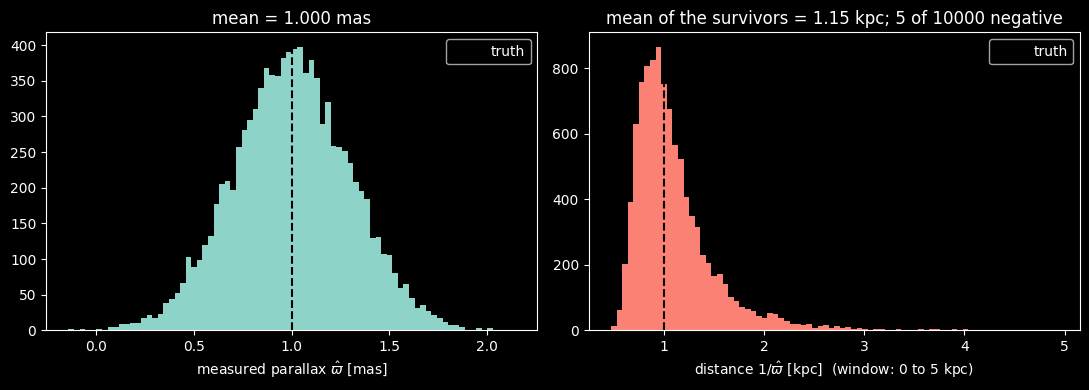

In [20]:
# 10,000 hypothetical Gaia missions measuring one star at 1 kpc: the parallaxes, and 1/parallax
demo_missions()


* Notice that the ten thousand measured parallaxes $\hat\varpi$ (left) are centred on the truth and symmetric
* the ten thousand distances $1/\hat\varpi$ (right) have a tail out to several kpc and a mean above the truth (in the title) - and a few missions came back with a negative parallax, the fitted-coefficient story from the Gaia slide!
* the parallax itself is centred on the truth; the bias comes from taking $1/\hat\varpi$


## Properties of estimators

* Hubble's 1929 expansion rate was an estimator too - a slope from 24 galaxies - and it came out about seven times too high because the distances that went in were biased

For an estimator $\hat\mu$ of a true value $\mu$ (a mean here, but this holds for any parameter), over the ensemble of datasets you could have been handed; $E[\cdot]$ is the average over that ensemble, i.e. over the ten thousand missions:

* bias $= E[\hat\mu] - \mu$; zero bias means unbiased ($\hat\varpi$ is, $1/\hat\varpi$ is not - a property of the estimator itself)
* variance $= E[(\hat\mu - E[\hat\mu])^2]$, the width of that ensemble; its square root is the error bar
* mean squared error $=$ bias$^2$ + variance
* consistent: bias and variance both go to zero as the data grow
* efficient: the variance is as small as the data allow (the Cramér-Rao bound, at the end of today)

Two ways to be wrong: scatter (the variance) and offset (the bias). The next slides are bias from the mathematics - from dividing, and from cutting on S/N (that is $\hat\varpi/\sigma_\varpi$, the signal-to-noise). The instrument's own bias comes after the sample mean.


<div style="font-size:1.35em; line-height:1.45; margin:0.6em 0;">

**How wrong $1/\hat\varpi$ is depends on one number: the fractional error $\sigma_\varpi/\varpi$.**

</div>

Let's sweep it: for each value we run the missions again and record the mean distance over the stars with positive parallax - and, for the obvious fix of keeping only $\hat\varpi/\sigma_\varpi > 5$, both the bias and the fraction of stars that survive.


In [21]:
# Sweep the fractional parallax error from 2% to 35%. At each value, run 200,000 missions and record:
#   the mean of 1/parallax minus the truth (the bias), with and without a 5-sigma cut,
#   and the fraction of stars the cut keeps.
def demo_bias_sweep(seed=20260908):
    rng = np.random.default_rng(seed)
    fracs = np.linspace(0.02, 0.35, 23)
    bias, bias_cut, kept = [], [], []
    for f in fracs:
        vh = rng.normal(1.0, f, 200_000)        # measured parallaxes, truth = 1 mas
        dh = 1.0 / vh                           # naive distances
        bias.append(dh[vh > 0].mean() - 1.0)    # drop the negative parallaxes, average the rest
        good = vh / f > 5.0                     # the S/N > 5 cut
        bias_cut.append(dh[good].mean() - 1.0 if good.sum() > 200 else np.nan)
        kept.append(good.mean())
    pct = 100 * fracs                           # plot in percent, to match the text
    fig, ax = plt.subplots(1, 2, figsize=(12, 4), gridspec_kw={'width_ratios': [3, 2]})
    ax[0].plot(pct, bias, 'o-', color='C3', label=r'mean of $1/\hat\varpi$ - truth')
    ax[0].plot(pct, bias_cut, 's--', color='C1', label=r'same, keeping only $\hat\varpi/\sigma_\varpi > 5$')
    ax[0].axhline(0, color='k', lw=0.8)
    ax[0].axvline(20, color='k', ls=':', lw=1)
    ax[0].set_xlabel(r'fractional parallax error  $\sigma_\varpi / \varpi$  [%]')
    ax[0].set_ylabel('bias in distance [kpc]  (truth = 1 kpc)')
    ax[0].legend()
    ax[1].plot(pct, 100 * np.array(kept), 'd-', color='C1')
    ax[1].axvline(20, color='k', ls=':', lw=1)
    ax[1].set_xlabel(r'fractional parallax error  [%]')
    ax[1].set_ylabel('stars surviving the S/N > 5 cut  [%]')
    ax[1].set_ylim(0, 105)
    plt.tight_layout()
    plt.show()
    i = np.searchsorted(fracs, 0.3)
    print(f"at 30% parallax error: naive bias {bias[i]:+.2f} kpc; with the 5-sigma cut {bias_cut[i]:+.2f} kpc, and the cut keeps {100*kept[i]:.0f}% of the stars")


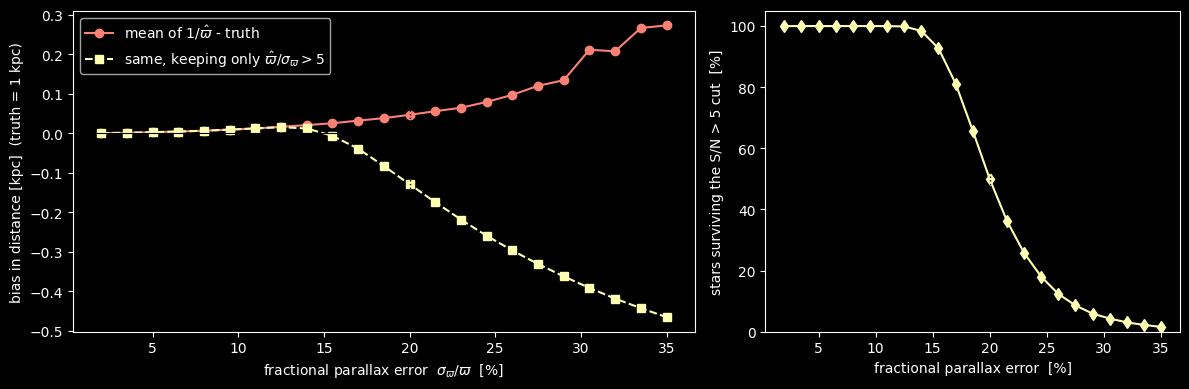

at 30% parallax error: naive bias +0.21 kpc; with the 5-sigma cut -0.39 kpc, and the cut keeps 4% of the stars


In [22]:
# sweep the fractional parallax error: bias of 1/parallax, with and without an S/N > 5 cut, and how many stars the cut keeps
demo_bias_sweep()


* a few percent error: negligible bias, dividing is fine (the bright stars)
* past 20% (the dotted line): the estimate drifts high ($1/\hat\varpi$ blows up when the noise scatters $\hat\varpi$ low, and the high side can't compensate)
* orange: the S/N cut throws away the draws that scattered low, so the survivors are biased the *other* way - and the right panel shows the price: at 30% error it keeps 4% of the stars
* this is Thursday's proper-motion cut again: cut on the thing you measure and you bias the thing you measure. Add the real spread of stars in distance and it becomes the Lutz-Kelker bias (1973) - the next slide


## Past 20% error, $1/\hat\varpi$ stops working

<img src="images/bailerjones_distance_from_parallax.png" alt="Scaled bias in black and standard deviation in blue of the one-over-parallax distance estimate against true fractional parallax error, with a zoomed right panel whose red line is the fraction of samples rejected for non-positive parallax" width="1000" style="display:block;margin:0 auto;">

<div style="font-size:0.8em; text-align:center; color:#666;">Bailer-Jones 2015, PASP 127, 994, Fig. 2. Right panel: the red line is the rejected fraction, on the same axes.</div>

Same experiment, for a realistic distribution of stars spread uniformly through a volume (ours were all parked at 1 kpc), with bias (black) and scatter (blue) of $1/\hat\varpi$ scaled by the true distance, against fractional error. This is the Lutz-Kelker effect (1973) with a realistic volume of stars. Bailer-Jones' conclusion is the same as above: beyond about 20% the estimator is not usable, and the remedy is a **prior** - a distribution for where stars are before you look at this one (next week).

## The sample mean

Most estimators you'll ever use are less exotic than $1/\varpi$. Let's assume we have $N$ independent measurements $x_i$ of the same thing, each with the same scatter $\sigma$. The sample mean

$$\bar x = \frac{1}{N}\sum_i x_i, \qquad E[\bar x] = \mu, \qquad \mathrm{Var}(\bar x) = \frac{\sigma^2}{N}$$

is unbiased, its error bar is $\sigma/\sqrt N$, and because both go to zero as $N$ grows it is consistent - as long as the scatter $\sigma$ exists. For Cauchy draws it doesn't, and the sample mean never settles down (Day 3). You've used the $\sqrt N$ a hundred times, and I want to show it on the SEGUE stars, because the [Fe/H] distribution is skewed and nowhere near Gaussian - remember Thursday's QQ-plot.

In [23]:
# Draw N SEGUE stars at random, take the mean of their [Fe/H]; repeat 2000 times and measure the scatter.
# Do that for N from 4 to 1024 and compare the scatter with sigma/sqrt(N).
def demo_sqrtN(seed=4570908):
    rng = np.random.default_rng(seed)
    Ns = np.array([4, 8, 16, 32, 64, 128, 256, 512, 1024])
    spread = np.array([np.std([rng.choice(feh, n, replace=False).mean() for _ in range(2000)]) for n in Ns])
    plt.figure(figsize=(7, 4))
    plt.loglog(Ns, spread, 'o', color='C0', label='scatter of the sample mean over 2000 draws')
    plt.loglog(Ns, feh.std() / np.sqrt(Ns), 'k--', label=r'$\sigma/\sqrt{N}$')
    plt.xlabel('N stars in the sample')
    plt.ylabel('scatter of the mean [dex]')
    plt.legend()
    plt.show()
    slope = np.polyfit(np.log(Ns), np.log(spread), 1)[0]   # a straight line on log-log axes: its slope should be -1/2
    print(f"measured slope = {slope:+.2f}   (expect -0.50)")
    assert abs(slope + 0.5) < 0.08


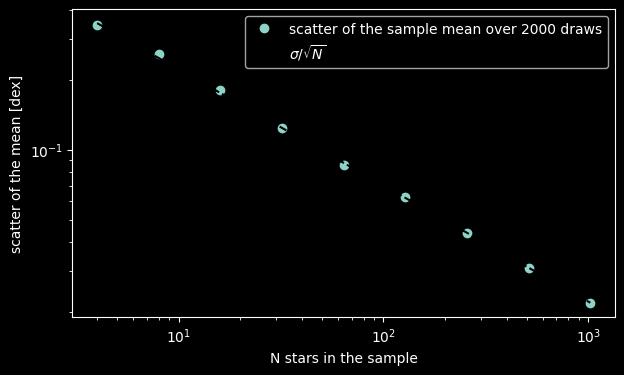

measured slope = -0.50   (expect -0.50)


In [24]:
# scatter of the mean of N SEGUE [Fe/H] values, N = 4 to 1024, against sigma/sqrt(N)
demo_sqrtN()


* Note that the scatter of the mean of $N$ stars falls as $N^{-1/2}$ (the slope in the printout) even though the [Fe/H] distribution is skewed - the $\sqrt N$ depends on $N$ alone!


## Why $N-1$

The $\sqrt N$ held on a skewed distribution, so the mean was easy. Now we estimate the scatter $\sigma$ itself from the same $N$ points. The obvious recipe, average the squared deviations from $\bar x$, is biased:

$$E\left[\frac{1}{N}\sum_i (x_i - \bar x)^2\right] = \frac{N-1}{N}\,\sigma^2$$

because $\bar x$ was fitted to these same points and sits a little closer to them than $\mu$ does. Divide by $N-1$ instead and the bias is gone (this is what `ddof=1` is doing). At $N = 4$ the naive version is 25% low; at $N = 1000$ you won't see the difference at all. Let's check it.

In [25]:
# 50,000 datasets of N Gaussian points (true variance 1). Average the naive variance (divide by N)
# and the corrected one (divide by N-1) over all of them.
def demo_ddof(N=4, seed=4570909):
    rng = np.random.default_rng(seed)
    draws = rng.normal(0.0, 1.0, size=(50_000, N))
    naive = draws.var(axis=1, ddof=0).mean()    # ddof=0: divide by N
    fixed = draws.var(axis=1, ddof=1).mean()    # ddof=1: divide by N-1
    print(f"N = {N}:  mean of the naive variance = {naive:.3f},  with N-1 = {fixed:.3f},  truth = 1.000")
    print(f"prediction for the naive one: (N-1)/N = {(N-1)/N:.3f}")
    assert abs(naive - (N-1)/N) < 0.02 and abs(fixed - 1.0) < 0.02


In [26]:
# 50,000 datasets of N = 4 points: the average of the naive variance (divide by N) and of the corrected one (N-1)
demo_ddof(N=4)


N = 4:  mean of the naive variance = 0.748,  with N-1 = 0.998,  truth = 1.000
prediction for the naive one: (N-1)/N = 0.750


* at $N = 4$ the naive variance averages $3/4$ of the truth, and dividing by $N-1$ removes the bias

## Random, and systematic

<div style="font-size:1.35em; line-height:1.45; margin:0.6em 0;">

**A random error averages down with $N$. A systematic does not - you need something whose true answer you already know.**

</div>

* everything so far was noise on an honest measurement: scatter, and the biases that come from what you do with it (dividing, cutting)
* the instrument itself can be off in the same direction for every star. No number of stars fixes that; only a reference with a known answer does


## The parallax zero point

<img src="images/lindegren2021_quasar_zp_vs_G.png" alt="Weighted mean Gaia EDR3 parallax of quasars in microarcseconds against G magnitude, scattered around a level of about minus seventeen microarcseconds rather than zero, with the dashed zero line above the points" width="640" style="display:block;margin:0 auto;">

<div style="font-size:0.8em; text-align:center; color:#666;">Lindegren et al. 2021, A&amp;A 649, A4, Fig. 5a. ESA/Gaia/DPAC.</div>

* quasars (accreting supermassive black holes at cosmological distances) have zero parallax for any purpose Gaia cares about, so here the truth is known
* Gaia's mean quasar parallax, binned by magnitude, sits at about $-17$ μas (a thousandth of a mas), where it should be zero: the parallax zero point, the instrument's own bias
* measure it on quasars, subtract it; every instrument has some version of this (e.g. a photometric zero point, the constant that turns counts into magnitudes)
* 17 μas is 2% of a 1 mas parallax and 17% of a 0.1 mas one, so it matters most for the faint stars


## Centroiding a star

<img src="images/star_psf_pixels.png" alt="A single star from a real Gaia CCD frame, enlarged so the individual pixels show, the light spread over a handful of pixels and slightly elongated along the scan direction" width="300" style="display:block;margin:0 auto;">

<div style="font-size:0.8em; text-align:center; color:#666;">One star from Gaia's first-light frame of NGC 1818, 48 by 48 pixels. ESA/DPAC/Airbus DS.</div>

* a star shows up on the detector as a blob of width $\sigma_{\rm PSF}$ (the point-spread function), made of $N_\gamma$ photons
* each photon is one noisy measurement of where the star is, so the centroid (the mean of the photon positions) is a sample mean, with the sample-mean error bar:

$$\sigma_x \;\gtrsim\; \frac{\sigma_{\rm PSF}}{\sqrt{N_\gamma}}$$

* every catalogue position has an error bar of this form (Gaia included); note the $\sqrt{N_\gamma}$ vs. the linear dependence on $\sigma_{\rm PSF}$. The $\gtrsim$ is deliberate: this is a floor no centroiding method beats, for a reason at the end of today

<div style="font-size:1.15em; line-height:1.4; margin:0.6em 0; padding:0.5em 0.8em; border-left:4px solid #444; background:#f2f2f2;">

💬 One line in chat: to halve your centroid error, would you rather have four times the exposure time, or half the seeing (the atmospheric blur that sets $\sigma_{\rm PSF}$ from the ground)? Say which and why.

</div>

## Gaia BH1

<img src="images/elbadry2023_gaiabh1_astrometric_orbit.png" alt="Left, the predicted on-sky path of the Gaia BH1 photocentre over six years with and without the orbit; middle and right, the roughly 2.7 milliarcsecond orbital ellipse from the joint fit and from Gaia astrometry alone" width="1000" style="display:block;margin:0 auto;">

<div style="font-size:0.8em; text-align:center; color:#666;">El-Badry et al. 2023, MNRAS 518, 1057, Fig. 3.</div>

Every point on this orbit is a centroid with the error bar from the centroiding slide, and we only know the black hole is there because those error bars were small enough to see the wobble.

* today's colloquium speaker found this: a Sun-like star at 480 pc whose **photocentre** (the centre of light - here just the star, since the companion emits none) traces a 2.7 mas ellipse on the sky every 185.6 days
* left: the predicted path over six years, with and without the orbit; middle and right: the ellipse from the joint fit of radial velocities plus astrometry, and from Gaia's astrometry alone
* the companion is a $9.62 \pm 0.18\,M_\odot$ black hole, the nearest known; the radial velocities are what confirmed its mass


## The likelihood

So far we've just asserted estimators. Where do they come from?

* each measurement $x_i$ has a probability of being what it is, given the true $\mu$: for Gaussian noise, a bell curve centred on $\mu$ with width $\sigma$
* independent measurements, so the probability of the *entire* dataset is the product:

$$\mathcal{L}(\mu) = \prod_i \frac{1}{\sqrt{2\pi}\sigma}\exp\left[-\frac{(x_i-\mu)^2}{2\sigma^2}\right]$$

* read as a function of $\mu$ with the data fixed, this is the **likelihood**
* note that it is not a probability distribution over $\mu$ - it doesn't integrate to one in $\mu$ (next week)

Let's look at ten measurements, each one's bell curve, and their product:


In [27]:
# N measurements of a true value mu_true with Gaussian noise. For a grid of candidate mu,
# compute each point's likelihood (a bell curve in mu centred on the measurement) and multiply them.
def demo_likelihood(N=10, mu_true=1.0, sigma=0.2, seed=42):
    rng = np.random.default_rng(seed)
    x = rng.normal(mu_true, sigma, N)
    mu_grid = np.linspace(0.5, 1.5, 1001)
    per_point = np.array([stats.norm.pdf(mu_grid, xi, sigma) for xi in x])   # one curve per measurement
    total = per_point.prod(axis=0)                                            # their product
    fig, ax = plt.subplots(1, 2, figsize=(11, 4))
    for L in per_point: ax[0].plot(mu_grid, L, color='C0', alpha=0.4)
    ax[0].plot(x, np.zeros(N), 'k|', ms=15, label=f'the {N} measurements')
    ax[0].set_xlabel(r'$\mu$')
    ax[0].set_title('one likelihood per point')
    ax[0].legend()
    ax[1].plot(mu_grid, total / total.max(), color='C3')
    ax[1].axvline(x.mean(), color='k', ls='--', label=f'sample mean = {x.mean():.3f}')
    ax[1].axvline(mu_true, color='C2', ls=':', label='truth')
    ax[1].set_xlabel(r'$\mu$')
    ax[1].set_title('their product')
    ax[1].legend()
    plt.tight_layout()
    plt.show()
    print(f"peak of the product at mu = {mu_grid[total.argmax()]:.3f};  sample mean = {x.mean():.3f}")
    assert abs(mu_grid[total.argmax()] - x.mean()) < 2e-3   # the peak IS the sample mean


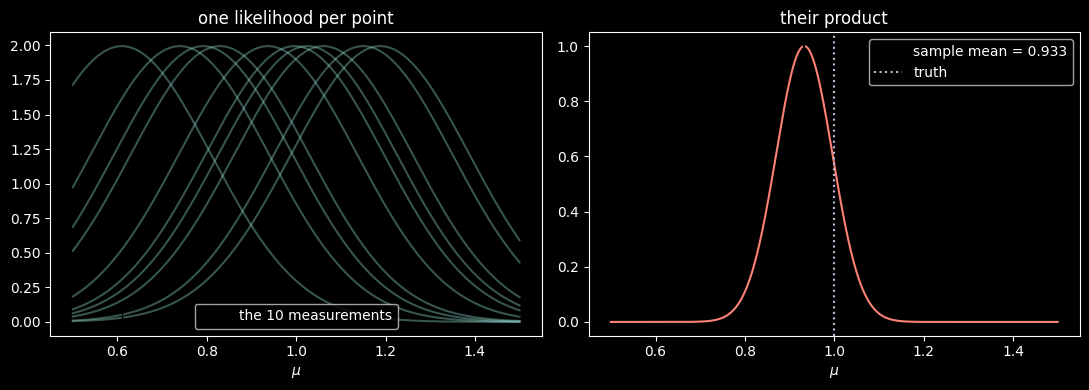

peak of the product at mu = 0.933;  sample mean = 0.933


In [28]:
# ten Gaussian measurements: each point's likelihood curve in mu, and their product
demo_likelihood(N=10)


* the product is narrower than any single bell curve, and it peaks at the sample mean - the next slide shows why


## Maximum likelihood and $\chi^2$

Take the log and the product becomes a sum:

$$\ln\mathcal{L}(\mu) = \text{const} - \frac{1}{2}\sum_i \frac{(x_i-\mu)^2}{\sigma^2} = \text{const} - \frac{\chi^2(\mu)}{2}$$

* that sum is the $\chi^2$ you have been minimising since Day 2: maximising the likelihood and minimising $\chi^2$ are *the same thing* when the noise is Gaussian
* the peak is the **maximum-likelihood estimate** (MLE); set $d\ln\mathcal{L}/d\mu = 0$ and out falls $\hat\mu = \bar x$, so the sample mean *is* the MLE - we've been using it on intuition, and this is what justifies the choice
* notice the assumptions: Gaussian noise, the same $\sigma$ for every point (Cauchy-distributed errors and the mean isn't even defined!)

The width of the peak is next.

## Curvature and the error bar

How wide is the peak? Taylor-expand $\ln\mathcal{L}$ about its maximum $\hat\mu$: the linear term vanishes there, so the first surviving term is

$$\ln\mathcal{L}(\mu) \approx \ln\mathcal{L}(\hat\mu) - \tfrac{1}{2}\,C\,(\mu-\hat\mu)^2, \qquad C = -\frac{d^2 \ln\mathcal{L}}{d\mu^2}\bigg|_{\hat\mu} = \frac{N}{\sigma^2}$$

* $C$, the curvature at the peak, is the **observed information**: how sharply *these* data pin $\mu$ down
* a parabola in $\ln\mathcal{L}$ is a Gaussian in $\mu$, and matching $e^{-\frac{1}{2}C(\mu-\hat\mu)^2}$ to $e^{-(\mu-\hat\mu)^2/2\sigma_\mu^2}$ gives $\sigma_\mu^2 = 1/C$ - for the mean, $\sigma/\sqrt N$, the sample-mean result again
* one $\sigma_\mu$ away, $\ln\mathcal{L}$ has dropped by $\tfrac{1}{2}$, so $\chi^2 = -2\ln\mathcal{L}$ has risen by 1: **the error bar is where $\chi^2$ rises by 1 above its minimum**
* we *define* the uncertainty on a maximum-likelihood estimate this way, and so does every fitting code - as long as the peak really is a parabola (the next demo shows one that isn't)

<div style="font-size:1.35em; line-height:1.45; margin:0.6em 0;">

**The width of the likelihood peak is your error bar.**

</div>

Let's do it the way a fitting code does it, for three sample sizes:


In [29]:
# The likelihood of a Gaussian mean at N = 5, 50, 500 points. Find the peak with a minimiser,
# measure the curvature there by finite differences, and shade the error bar 1/sqrt(curvature).
def demo_curvature(seed=20260909):
    rng = np.random.default_rng(seed)
    fig, ax = plt.subplots(1, 3, figsize=(13, 3.6))
    for a, N in zip(ax, [5, 50, 500]):
        xs = rng.normal(1.0, 0.2, N)
        nll = lambda m: 0.5 * np.sum((xs - m)**2) / 0.2**2        # negative log-likelihood = chi^2 / 2
        res = minimize(lambda m: nll(m[0]), x0=[0.8])
        mu_hat, h = res.x[0], 1e-4
        curv = (nll(mu_hat + h) - 2 * nll(mu_hat) + nll(mu_hat - h)) / h**2   # second derivative, numerically
        err = 1 / np.sqrt(curv)
        grid = np.linspace(0.7, 1.3, 600)
        a.plot(grid, np.exp(-np.array([nll(g) for g in grid]) + nll(mu_hat)), color='C3')
        a.axvline(1.0, color='C2', ls=':')
        a.axvspan(mu_hat - err, mu_hat + err, color='C3', alpha=0.15)
        a.set_title(f'N={N}: {mu_hat:.3f} ± {err:.3f}   (σ/√N = {0.2/np.sqrt(N):.3f})')
        a.set_xlabel(r'$\mu$')
    plt.tight_layout()
    plt.show()


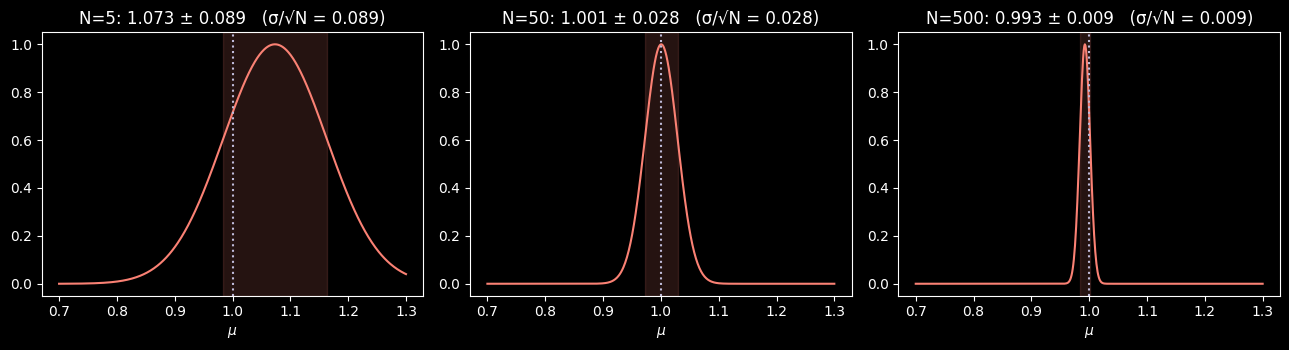

In [30]:
# likelihood of a Gaussian mean at N = 5, 50, 500, with the error bar from the curvature at the peak shaded
demo_curvature()


* Notice how in every panel the shaded band from the curvature matches $\sigma/\sqrt N$
* $N = 5$ to $N = 500$: the peak sharpens by $\sqrt{100} = 10$
* for this Gaussian mean, $\chi^2(\mu)$ is *exactly* a parabola, so the curvature could not have failed. Let's switch to a Poisson rate $\lambda$ from five counts, where it is only a parabola near the minimum:


In [31]:
# Five Poisson counts with an unknown rate lambda. Plot -2 ln L(lambda) above its minimum,
# and the parabola that has the same curvature at the minimum. The horizontal line is the +1 rule for a 1-sigma error bar.
def demo_chi2_parabola(counts=(2, 4, 1, 3, 5)):
    counts = np.asarray(counts)
    N = len(counts)
    lam = np.linspace(0.8, 7.0, 600)
    lam_hat = counts.mean()                       # the maximum-likelihood rate is the mean count
    # Poisson log-likelihood, up to a constant: sum(k ln lambda - lambda); we plot -2 ln L relative to its minimum
    m2lnL = 2 * (N * lam - counts.sum() * np.log(lam)) - 2 * (N * lam_hat - counts.sum() * np.log(lam_hat))
    curv = 2 * counts.sum() / lam_hat**2          # second derivative of -2 ln L at the minimum
    parab = 0.5 * curv * (lam - lam_hat)**2       # the parabola with that curvature
    plt.figure(figsize=(7, 4))
    plt.plot(lam, m2lnL, color='C3', lw=2, label=r'$-2\ln\mathcal{L}(\lambda)$, Poisson, 5 counts')
    plt.plot(lam, parab, 'k--', label='parabola with the same curvature at the minimum')
    plt.axhline(1, color='C0', lw=0.8)
    plt.text(6.2, 1.15, r'$\Delta = 1$', color='C0')
    plt.ylim(-0.2, 8)
    plt.xlabel(r'rate $\lambda$ [counts per exposure]')
    plt.ylabel(r'$-2\ln\mathcal{L}$ above the minimum')
    plt.legend()
    plt.show()
    # where the real curve crosses +1, on each side of the minimum
    left = lam[lam < lam_hat][np.where(m2lnL[lam < lam_hat] < 1)[0][0]]
    right = lam[lam > lam_hat][np.where(m2lnL[lam > lam_hat] > 1)[0][0]]
    print(f"MLE lambda = {lam_hat:.2f};  parabola error bar = ±{np.sqrt(2/curv):.2f};  where -2lnL actually crosses +1: {left:.2f} to {right:.2f}  (i.e. -{lam_hat-left:.2f} / +{right-lam_hat:.2f})")


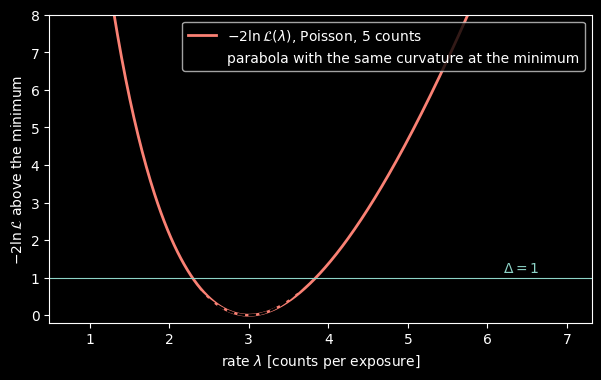

MLE lambda = 3.00;  parabola error bar = ±0.77;  where -2lnL actually crosses +1: 2.30 to 3.84  (i.e. -0.70 / +0.84)


In [32]:
# -2 ln L for a Poisson rate from five counts, and the parabola with the same curvature at the minimum
demo_chi2_parabola()


* red: $-2\ln\mathcal{L}$ for the Poisson rate: it climbs steeply on the left and slowly on the right
* black dashed: the parabola with the same curvature at the minimum; the horizontal line is the $\Delta\chi^2 = 1$ rule from the curvature slide
* the parabola's symmetric error bar and the true crossing points are in the printout: close at the minimum, wrong in the wings. A minimiser's `hess_inv` (its estimate of the inverse curvature at the answer) makes exactly this approximation


## Expected information

* we measured the curvature above on *one* dataset; if we average it over all the datasets we could have drawn we get the **Fisher information**

$$I(\mu) = E\left[-\frac{\partial^2 \ln\mathcal{L}}{\partial\mu^2}\right] = N \int \frac{1}{p(x\,|\,\mu)}\left(\frac{\partial p}{\partial\mu}\right)^2 dx$$

* i.e. how fast the probability of each possible $x$ changes when $\mu$ moves, weighted by how often that $x$ occurs (the two forms agree because $\int p\,dx = 1$ for every $\mu$: differentiate that twice and the second-derivative term cancels)
* a property of the experiment, before any data arrive: one integral per measurement, times $N$, because independent measurements add information
* observed information = what your data's peak looks like; expected (Fisher) information = what the experiment delivers on average, and the one the Cramér-Rao bound uses
* for a Gaussian the integral is $1/\sigma^2$, and you get $N/\sigma^2$ back. For a star's image on a detector:


In [33]:
# The Fisher information per photon for a Gaussian PSF of width sig_psf, integrated numerically:
# I = integral of (dp/dx0)^2 / p over x, where p is the PSF and x0 the star's position.
# Then the bound 1/sqrt(N I) for N photons, next to the sample-mean guess sig_psf/sqrt(N).
def demo_fisher_integral(sig_psf=0.5):
    x = np.linspace(-6, 6, 200_001)
    h = 1e-5
    p = stats.norm.pdf(x, 0.0, sig_psf)                                        # the PSF
    dp = (stats.norm.pdf(x, h, sig_psf) - stats.norm.pdf(x, -h, sig_psf)) / (2 * h)   # its derivative with respect to the star position
    I_one = np.trapezoid(dp**2 / p, x)                                         # information per photon
    for N in [100, 10_000]:
        print(f"N = {N:>6} photons:  1/sqrt(N I) = {1/np.sqrt(N*I_one):.4f} px,   sigma_PSF/sqrt(N) = {sig_psf/np.sqrt(N):.4f} px")
    assert abs(1/np.sqrt(I_one) - sig_psf) < 1e-3


In [34]:
# Fisher information per photon for a Gaussian PSF, integrated numerically, and the bound for N photons
demo_fisher_integral()


AttributeError: module 'numpy' has no attribute 'trapezoid'

* numerically integrating the per-photon information for a Gaussian PSF gives back $\sigma_{\rm PSF}/\sqrt{N_\gamma}$ to four decimals, i.e. the centroid error bar from earlier - and the $\gtrsim$ on that slide was this: no centroid can beat it

## The Cramér-Rao bound

If you have an unbiased estimator of a parameter $\mu$, its variance has a minimum possible value:

$$\mathrm{Var}(\hat\mu) \;\geq\; \frac{1}{I(\mu)}$$

* the Fisher information is the best case you can do with these data if your estimator is unbiased; an estimator that actually attains this limit is said to be **efficient** (remember, $I$ is the *expected* information, the experiment's average over datasets)
* an ML estimator gets there with a large number of samples; the sample mean is there already ($\sigma^2/N$ equals $1/I$)
* the bound is a property of the *experiment*; you can compute it before you have data or an estimator. This is why it's the check on your Lab 02 error bars
* a *biased* estimator can sit below it on purpose - that is what a prior buys you, next week; the other ways this bound can mislead come after the matrix and the corner plot

<div style="font-size:1.35em; line-height:1.45; margin:0.6em 0;">

**An error bar systematically below the Cramér-Rao bound needs a reason - a bias you chose on purpose - or it is wrong.**

</div>


## More than one parameter

A real fit has several parameters (a position *and* a background level; a period, phase and amplitude), and the Fisher information becomes a matrix of second derivatives over the parameters $\theta_1, \theta_2, \ldots$ (its inverse is the **covariance matrix**: the ensemble average of the product of two parameters' errors, $C_{ij} = E[(\hat\theta_i-\theta_i)(\hat\theta_j-\theta_j)]$),

$$I_{ij} = E\left[-\frac{\partial^2 \ln\mathcal{L}}{\partial\theta_i\,\partial\theta_j}\right]$$

* the covariance of the estimates is its **inverse**; the error bar on one parameter is the square root of that parameter's diagonal entry *of the inverse* - invert first, then read off
* $1/I_{ii}$ on its own is a different, smaller number: the error you'd get if you already knew every other parameter (which you don't)
* the off-diagonal entries encode the **correlations** between parameters: $r = C_{ij}/\sqrt{C_{ii}C_{jj}}$, the correlation coefficient, between $-1$ and $1$
* in Lab 02 you will build this matrix yourself, numerically, and invert it

The same object at 2, 3 and 8 parameters, from fits of a continuum plus emission lines to one spectrum:


In [ ]:
# Covariance of a least-squares fit, for a realistic model: a spectrum with a continuum and Gaussian emission lines.
# Fisher matrix I = J^T J / sigma^2 (J = derivative of the model at each pixel with respect to each parameter);
# the covariance is its inverse, and the correlation matrix is the covariance with the diagonal scaled to 1.
def demo_covariance(sigma=0.05, seed=4570912):
    rng = np.random.default_rng(seed)
    x = np.linspace(-10, 10, 200)                                   # wavelength pixels, arbitrary units
    def gauss(x, A, x0, w): return A * np.exp(-0.5 * ((x - x0) / w)**2)
    def corr_of(model, theta, names):
        h = 1e-5
        theta = np.asarray(theta, float)
        J = np.array([(model(theta + h*e) - model(theta - h*e)) / (2*h) for e in np.eye(len(theta))]).T   # numerical Jacobian
        C = np.linalg.inv(J.T @ J) * sigma**2                       # covariance of the fitted parameters
        return C, C / np.sqrt(np.outer(np.diag(C), np.diag(C))), names
    # 2 parameters: one line's amplitude and width, centre known
    C2, R2, n2 = corr_of(lambda t: gauss(x, t[0], 0.0, t[1]), [1.0, 1.5], [r'$\theta_1$ amp', r'$\theta_2$ width'])
    # 3 parameters: amplitude, centre, width
    C3, R3, n3 = corr_of(lambda t: gauss(x, t[0], t[1], t[2]), [1.0, 0.0, 1.5], [r'$\theta_1$ amp', r'$\theta_2$ centre', r'$\theta_3$ width'])
    # 8 parameters: continuum level + slope, and two lines (amp, centre, width each)
    C8, R8, n8 = corr_of(lambda t: t[0] + t[1]*x + gauss(x, t[2], t[3], t[4]) + gauss(x, t[5], t[6], t[7]),
                         [0.2, 0.01, 1.0, -3.0, 1.5, 0.6, 4.0, 1.0], [rf'$\theta_{i}$' for i in range(1, 9)])
    fig, ax = plt.subplots(1, 4, figsize=(15, 3.8), gridspec_kw={'width_ratios': [1.2, 0.8, 1, 1.4]})
    s = rng.multivariate_normal([0, 0], C2, 3000)                    # draws from the 2-parameter covariance
    ax[0].plot(s[:, 0], s[:, 1], '.', ms=2, alpha=0.3, color='C0')
    ax[0].set_xlabel(r'error in $\theta_1$ (amplitude)')
    ax[0].set_ylabel(r'error in $\theta_2$ (width)')
    ax[0].set_title(f'2 parameters: one ellipse, r = {R2[0,1]:+.2f}')
    for a, R, names, title in [(ax[1], R2, n2, 'its 2x2 correlation matrix'), (ax[2], R3, n3, '3 parameters'), (ax[3], R8, n8, '8 parameters: continuum + two lines')]:
        n = len(names)
        a.imshow(R, cmap='RdBu', vmin=-1, vmax=1)
        a.set_title(title)
        a.set_xticks(range(n))
        a.set_yticks(range(n))
        a.set_xticklabels([nm.split()[0] for nm in names])
        a.set_yticklabels(names if n < 8 else [nm.split()[0] for nm in names])
        for i in range(n):
            for j in range(n): a.text(j, i, f'{R[i,j]:+.2f}', ha='center', va='center', fontsize=8 if n < 8 else 6)
    plt.tight_layout()
    plt.show()
    print("8 parameters: theta_1, theta_2 = continuum level and slope; theta_3-5 = line 1 amplitude, centre, width; theta_6-8 = line 2")
    print(f"amplitude and width of a line are anti-correlated (r = {R2[0,1]:+.2f}); a line's centre is nearly independent of both; the two lines barely talk to each other")


In [ ]:
# covariance of a spectrum fit (continuum + emission lines) at 2, 3 and 8 parameters: an ellipse, then correlation matrices
demo_covariance()


* left: two parameters, the amplitude and width of one emission line, give one tilted ellipse - and the same information as a 2×2 correlation matrix next to it (the tilt of the ellipse is the correlation: $r$ is the sign and strength of the tilt)
* 3 and 8 parameters: mostly diagonal, as real fits are - a line's centre is nearly independent of its amplitude and width, and two well-separated lines barely talk to each other. The off-diagonal entries that are not zero are the ones that widen an error bar, and reading one error bar means inverting the whole matrix first


## Multimodal likelihoods

* the curvature trick assumes the peak is a parabola *and that there is one of them*
* `scipy.optimize.minimize` will give you `hess_inv` for any surface: an *approximation* to the inverse curvature, built up from the gradient steps it took during the search rather than measured at the answer. It describes the neighbourhood of whichever peak it found, nothing else
* in practice, if the error bar matters, compute the second derivative yourself and look at the surface
* a sharp local peak next to another mode reports a tiny error bar and misses the other answers entirely

It is always a good idea to visualize the likelihood surface when in doubt - the same rule as looking at your data. Let's look at two parameters, with six measurements taken one night apart:


In [ ]:
# Six nightly observations of a sinusoid with unknown period and phase. Compute chi^2 on a grid of
# (period, phase), turn it into a likelihood, and show it as a corner plot: the 2-D map plus each parameter alone.
def demo_period_alias(P_true=2.3, phi_true=0.7, n_epochs=6, sig=0.15, seed=11):
    rng = np.random.default_rng(seed)
    t = np.sort(np.arange(n_epochs) * 1.0 + rng.uniform(-0.05, 0.05, n_epochs))   # one observation per night, near-integer-day spacing
    y = np.sin(2*np.pi*t/P_true + phi_true) + rng.normal(0, sig, n_epochs)
    P = np.linspace(0.6, 6.0, 1200)
    phi = np.linspace(0, 2*np.pi, 240)
    PP, FF = np.meshgrid(P, phi, indexing='ij')
    # chi^2 at every (period, phase) grid point at once: the model is evaluated for all six epochs (last axis) and summed
    chi2 = ((y[None, None, :] - np.sin(2*np.pi*t[None, None, :]/PP[..., None] + FF[..., None]))**2).sum(-1) / sig**2
    L = np.exp(-0.5 * (chi2 - chi2.min()))                                          # likelihood, normalised to its peak
    fig = plt.figure(figsize=(9, 7))
    gs = fig.add_gridspec(2, 2, width_ratios=[3, 1], height_ratios=[1, 3], hspace=0.05, wspace=0.05)
    ax_top = fig.add_subplot(gs[0, 0])
    ax_main = fig.add_subplot(gs[1, 0])
    ax_right = fig.add_subplot(gs[1, 1])
    ax_main.contourf(P, phi, L.T, levels=20, cmap='Greys')
    ax_main.set_xlabel('period P [d]')
    ax_main.set_ylabel('phase [rad]')
    ax_main.axvline(P_true, color='C2', ls=':', label='true period')
    ax_main.legend(loc='upper right')
    ax_top.plot(P, L.sum(1) / L.sum(1).max(), color='C3')
    ax_top.set_xlim(P[0], P[-1])
    ax_top.set_xticks([])
    ax_top.set_ylabel('L(P)')   # period alone (phase summed out)
    ax_right.plot(L.sum(0) / L.sum(0).max(), phi, color='C3')
    ax_right.set_ylim(phi[0], phi[-1])
    ax_right.set_yticks([])
    ax_right.set_xlabel('L(phase)')   # phase alone
    plt.show()
    Lp = L.sum(1)
    peaks = [P[i] for i in range(1, len(P)-1) if Lp[i] > Lp[i-1] and Lp[i] > Lp[i+1] and Lp[i] > 0.2*Lp.max()]
    print(f"{n_epochs} nightly epochs; periods with a likelihood peak above 20% of the best: {', '.join(f'{v:.2f}' for v in peaks)} d   (truth {P_true} d; 1/P ± 1 cycle/day predicts aliases at {1/(1/P_true+1):.2f} and {1/abs(1/P_true-1):.2f} d)")


In [ ]:
# six nightly observations of a sinusoid: the likelihood over (period, phase) as a corner plot
demo_period_alias()


* a **corner plot**: the big panel is the likelihood over two parameters at once (period and phase), the side panels are each parameter alone with the other summed out; with three parameters it grows to a 3×3 grid
* one observation per night means a signal at period $P$ is indistinguishable from one at $1/(1/P \pm 1\ \mathrm{cycle/day})$: **aliases**, the islands in the printout - and here the true period is not even the tallest one. Each island is tilted: period and phase are correlated within it, the same off-diagonal entry as on the matrix slide
* a curvature error bar at any one island misses the rest; the remedy is more data at different spacing, and no minimiser helps


## Where Fisher stops

<table style="border:none; margin:0 auto;"><tr style="border:none;"><td style="border:none; padding:4px; vertical-align:top;"><img src="images/raghunathan2026_fig5_fisher_vs_mcmc.png" alt="Corner plot for three cosmological parameters from LSST supernovae: grey Fisher ellipses against red banana-shaped MCMC posteriors that bend away from the ellipses" width="400" style="display:block;margin:0 auto;"></td><td style="border:none; padding:4px; vertical-align:top;"><img src="images/sarcevic2026_fig2c_fisher_bias.png" alt="Two-parameter Fisher contours, solid for the fiducial data and dashed for a biased data vector, the dashed ellipse shifted away from the solid one by about one contour width" width="300" style="display:block;margin:0 auto;"></td></tr></table>

<div style="font-size:0.8em; text-align:center; color:#666;">Left: Raghunathan, Mitra, Šarčević et al. 2026, Fig. 5 - Fisher (grey) against the sampled likelihood (red) for the same supernova forecast; the ellipses cannot bend. Right: Šarčević et al. 2026 (DerivKit), Fig. 2c - a biased data vector moves the whole ellipse, and the ellipse's width says nothing about it.</div>

* unbiased only: the bound is on unbiased estimators. A biased estimator can have a smaller variance, and even a smaller mean squared error - that is what a prior buys, next week
* asymptotic: the MLE reaches the bound as $N \to \infty$; at five Poisson counts the curve was not a parabola
* regular: the likelihood must be smooth in $\mu$, and $\mu$ must not decide which $x$ are possible (a uniform on $[0, \mu]$ breaks it)
* one peak, no walls: multimodal likelihoods and parameters pinned at a physical boundary ($r \geq 0$, neutrino masses $\geq 0$) are not ellipses, and the Fisher ellipse misreports them
* expected vs observed: your one dataset's curvature scatters around $I(\mu)$, so one error bar a little under $1/I$ is noise; a systematic one is a bug

Fisher tells you the best case for a well-behaved problem. When any of these fail, you sample the likelihood instead - next week.

**EXTRA** in the notebook, after this slide: Fisher in practice - how survey forecasts are made, and why the derivatives are the hard part. We return to it on Sep 15/17.


## EXTRA: Fisher in practice - forecasts

*Not presented today; we come back to this on Sep 15/17.*

<img src="images/raghunathan2026_fig8_w0wa_bao_sn_cmb.png" alt="Forecast constraints on the dark energy parameters w0 and wa: wide orange DESI BAO contours, red LSST supernova contours crossing them at a different angle, and a small navy contour where the two overlap, shrinking further to green when CMB data are added" width="560" style="display:block;margin:0 auto;">

<div style="font-size:0.8em; text-align:center; color:#666;">Raghunathan, Mitra, Šarčević et al. 2026, ApJ 1003, 246, Fig. 8 (a UIUC/CAPS-led DESC paper). A forecast for LSST-Y3 supernovae, DESI-DR3 BAO, SPT-3G CMB.</div>

* the bound is a property of the experiment, so you can compute it *before* building the experiment: model the data, take the derivatives, invert the matrix, read off the ellipse. That is a **Fisher forecast**, and it is how every survey you will work on was designed
* the tilts are the point: BAO and supernovae each leave a long degeneracy in $(w_0, w_a)$, in different directions, and the combination is far smaller than either
* the ellipse is only as good as the derivatives and the covariance that went into it - the next cell


## EXTRA: Fisher in practice - the derivatives

<table style="border:none; margin:0 auto;"><tr style="border:none;"><td style="border:none; padding:4px; vertical-align:top;"><img src="images/rogozenski2026_fig2_defom_vs_stepsize.png" alt="Dark energy figure of merit against the normalised finite-difference step size for nine combinations of power-spectrum code and derivative method: the curves jump by factors of several at small step sizes and settle onto flat lines only for steps above about one percent of the prior range" width="520" style="display:block;margin:0 auto;"></td><td style="border:none; padding:4px; vertical-align:top;"><img src="images/sarcevic2026_fig1b_derivative_scatter.png" alt="Histogram of derivative estimates at one point from five hundred noise realisations: the finite-difference estimates spread from minus one hundred to plus one hundred while the adaptive polynomial-fit estimates cluster tightly around the true value of about one" width="440" style="display:block;margin:0 auto;"></td></tr></table>

<div style="font-size:0.8em; text-align:center; color:#666;">Left: Rogozenski et al. 2026 (DESC's Augur, arXiv:2608.03876), Fig. 2, LSST Year 1. Right: Šarčević, van der Wild &amp; Trendafilova 2026 (DerivKit, arXiv:2602.08078), Fig. 1b.</div>

* $I$ is built from $\partial p/\partial\theta$, and for a real model that derivative is numerical: a finite difference with some step size
* left: the dark energy figure of merit (the inverse area of the $w_0$-$w_a$ ellipse) for the LSST forecast, against that step size. Too small a step and the forecast swings by factors of several; it settles only above about 1% of the prior range, and the stable value differs between power-spectrum codes
* right: five hundred noisy evaluations of the same function - finite differences scatter over $\pm 100$ around a true derivative of 1; a local polynomial fit gets it
* the same problem with the covariance: estimate it from $N_s$ simulations and its inverse is biased high, so the forecast is too optimistic unless corrected (Hartlap et al. 2007; Dodelson &amp; Schneider 2013)


## An aside on Fisher

* R. A. Fisher (1890-1962): maximum likelihood, the information named after him, analysis of variance, the design of experiments - much of the statistics you will use
* he was also a leading eugenicist: a founder of the Cambridge University Eugenics Society, professor of eugenics at UCL, and a defender of the movement after the war
* in 2020 Gonville & Caius College removed the window commemorating him and UCL renamed its Fisher Centre
* we use the mathematics; you should also know who he was


## Confidence intervals

The width of the peak was half of today; the other half is what that width promises. One experiment is $N$ measurements. It gives one estimate $\hat\mu$ and one interval, $\hat\mu \pm \sigma/\sqrt N$, which we call a 68% interval. What that means to a frequentist:

* imagine repeating the whole experiment $M$ times: $M$ datasets, $M$ estimates, $M$ intervals
* the **coverage** of the recipe is the fraction of those $M$ intervals that contain the true $\mu$; a correct 1σ recipe has 68% coverage, and that is what makes it a **confidence interval**
* the truth never moves; the intervals scatter around it. In your one experiment you get one interval, and you never learn whether it is one of the 68%
* so let's run the $M$ repeats ourselves:


In [ ]:
# 5000 hypothetical experiments, each with N measurements of mu_true. For each one build the interval
# mean ± sigma/sqrt(N) and check whether it contains the truth. Then draw the first 60 intervals.
def demo_coverage(mu_true=1.0, sigma=0.2, N=10, trials=5000, seed=4570910):
    rng = np.random.default_rng(seed)
    xs = rng.normal(mu_true, sigma, size=(trials, N))
    lo = xs.mean(1) - sigma/np.sqrt(N)
    hi = xs.mean(1) + sigma/np.sqrt(N)
    covered = (lo < mu_true) & (mu_true < hi)                        # did this interval catch the truth?
    print(f"{trials} hypothetical datasets of N={N}: the 1-sigma interval contains the truth {100*covered.mean():.1f}% of the time  (promise: 68.3%)")
    assert abs(covered.mean() - 0.683) < 0.02
    plt.figure(figsize=(9, 3.2))
    for i in range(60): plt.plot([lo[i], hi[i]], [i, i], color='C0' if covered[i] else 'C3', lw=2)
    plt.axvline(mu_true, color='k', ls='--')
    plt.yticks([])
    plt.xlabel(r'interval for $\mu$   (red: missed the truth)')
    plt.show()


In [ ]:
# 5000 repeats of an N = 10 experiment: does the 1-sigma interval contain the truth? draw the first 60
demo_coverage()


* sixty of the five thousand intervals, one per row: the red ones missed the truth - about one in three, as promised (and without the dashed line you could not tell which)


## Bootstrap vs. the formula

That check assumed we knew $\sigma$. In practice the error bar comes from the same $N$ points, two ways:

* formula: $s/\sqrt N$, the sample scatter $s$ plugged into $\sigma/\sqrt N$ (free; assumes Gaussian noise and a decent $N$)
* bootstrap (Tuesday): resample the $N$ points with replacement, recompute the mean, take the spread over thousands of resamples (no noise model needed; fails for extremes and other non-smooth statistics)

The question is how reliable each error bar is at $N = 8$. One draw of eight proves nothing, so let's do it four thousand times and compare each error bar to the true one:


In [ ]:
# Error bar on the mean of 8 SEGUE stars, two ways: the formula s/sqrt(8), and the bootstrap.
# First one draw of 8; then 4000 draws of 8, each error bar divided by the true one (from the whole population).
def demo_bootstrap(seed=4570911):
    rng = np.random.default_rng(seed)
    true_se = feh.std() / np.sqrt(8)   # the error bar we are trying to estimate
    x8 = rng.choice(feh, 8, replace=False)                                     # one draw of 8 stars
    boot = np.array([rng.choice(x8, 8, replace=True).mean() for _ in range(5000)])   # resample those 8 with replacement, 5000 times
    print(f"one draw of 8:  formula {x8.std(ddof=1)/np.sqrt(8):.3f} dex,  bootstrap {boot.std():.3f} dex,  population truth {true_se:.3f} dex")
    draws = np.array([rng.choice(feh, 8, replace=False) for _ in range(4000)])          # 4000 draws of 8
    r_formula = draws.std(axis=1, ddof=1) / np.sqrt(8) / true_se                         # formula error bar / truth, per draw
    idx = rng.integers(0, 8, size=(4000, 500, 8))                                        # 500 bootstrap resamples per draw
    r_boot = np.take_along_axis(draws[:, None, :], idx, axis=2).mean(axis=2).std(axis=1) / true_se
    plt.figure(figsize=(7, 3.6))
    plt.hist(r_formula, bins=60, alpha=0.6, color='C0', label='formula  s/√N')
    plt.hist(r_boot, bins=60, alpha=0.6, color='C3', label='bootstrap')
    plt.axvline(1, color='k', ls='--')
    plt.xlabel('estimated error bar / true error bar, 4000 draws of 8 stars')
    plt.ylabel('count')
    plt.legend()
    plt.show()
    print(f"median ratio: formula {np.median(r_formula):.2f}, bootstrap {np.median(r_boot):.2f};  "
          f"{100*(r_formula < 0.5).mean():.0f}% of formula error bars are low by more than 2x, {100*(r_formula > 1.2).mean():.0f}% high by more than 20%")


In [ ]:
# error bar on the mean of 8 SEGUE stars, formula vs bootstrap, once and then 4000 times
demo_bootstrap()


* one draw of eight: both error bars come from the same eight points, and neither knows about the population's tail
* four thousand draws: on average both are roughly right (medians in the printout); the bootstrap runs a little low because resampling *from* the eight points treats their own scatter as the population's - that is the divide-by-$N$ variance from the $N-1$ slide, $\sqrt{7/8} = 0.94$ at $N = 8$
* on any given day either can be off by a factor of two in either direction (fractions in the printout): with 8 points the tail is invisible to both


## Wrapping up estimators

* an estimator is a function of the data and has a distribution of its own: bias, variance, and bias$^2$ + variance (the mean squared error); consistent if both shrink with $N$, efficient if it sits at the lower limit
* the likelihood is where estimators come from; maximising it is minimising $\chi^2$; the peak is the estimate and the curvature is the error bar (when the peak is a parabola)
* the Fisher information sets the Cramér-Rao lower limit; an error bar under it needs a reason, or it is wrong
* several parameters: invert the matrix, then read the diagonal; look at the corner plot for the islands
* 68% is a statement about repeat experiments, and you can check it by running them
* the parallax was the worked example: $\hat\varpi$ is unbiased and $1/\hat\varpi$ is not, the S/N cut makes it worse, the zero point is a bias you can measure - and the $-0.3 \pm 0.5$ mas star has no distance estimate today; it needs a prior, next week

**Lab 02** posts Thursday: a photon list, a position, and an error bar you have to defend against the bound.


## Before you go

* **Lab 01** is due tomorrow, Wed Sep 9 at Noon (fork then PR, as always).
* Nothing from today is collected.
* Next week: priors, and the Bayesian answer to the negative parallax.